In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Dimensionless equation of motion**

$$\tau = \omega t \\[10 pt]
\implies t = \frac{\tau}{\omega} \\[10 pt]
\implies \frac{d}{dt} = \omega \frac{d}{d\tau} \tag{a.1}$$

$$\xi = \frac{x}{a} \\[10 pt]
\implies x = a\xi \\[10 pt]
\implies \dot{x} = a\frac{d\xi}{dt} = a\omega\frac{d\xi}{d\tau} = a\omega\xi' \tag{a.2}$$
$$\implies \ddot{x} = a\omega\frac{d}{dt}\left(\frac{d\xi}{d\tau}\right) = a\omega^2\xi'' \tag{a.3}$$

Equation of motion is:
$$m\ddot{x} = -\frac{dV}{dx} + F_{drag} \\[10 pt]
\implies ma\omega^2\xi'' = -\frac{dV}{dx} - ma\omega^2sgn(\dot{x}) \\[10 pt]
\implies \xi'' = -\frac{1}{ma\omega^2}\frac{dV}{dx} - sgn(\xi')$$ \\

$$V(x) = 
\begin{cases}
    \frac{1}{2}m\omega^2(x+a)^2 & x \le a \\
    0 & |x|<a \\
    \frac{1}{2}m\omega^2(x-a)^2 & x \ge a
\end{cases} \\[10 pt]
\implies \frac{dV}{dx} = ma\omega^2
\begin{cases}
    \xi+1 & \xi \le 1 \\
    0 & |\xi| < 1 \\
    \xi-1 & \xi \ge 1
\end{cases}$$

Substituting this into the equation of motion, we get:
$$\xi'' = -\frac{1}{ma\omega^2}\frac{dV}{dx} - sgn(\xi')$$
since $sgn(\dot{x}) = sgn(a\omega\xi') = sgn(\xi')$

$$\xi'' = 
\begin{cases}
    -(\xi+1) - sgn(\xi') & \xi \le -1 \\
    -sgn(\xi') & |\xi| \le 1 \\
    -(\xi - 1) - sgn(\xi') & \xi \ge 1
\end{cases} \tag{a.4}$$

**Initial conditions:**
$$x(0) = 0 \implies \xi(0) = 0 \\[5 pt]
\dot{x}(0) = a\omega \implies a\omega\xi'(0) = a\omega \implies \xi'(0) = 1$$

**Dimensionless Potential:**
$$V(\xi) = 
\begin{cases}
    \frac{1}{2}m\omega^2(a\xi + a)^2 & a\xi \le -a \\
    0 & |a\xi| < a \\
    \frac{1}{2}m\omega^2(a\xi - a)^2 & a\xi \ge a \\
\end{cases} \\[10 pt]
\implies \nu(\xi) = 
\begin{cases}
    \frac{1}{2}(\xi+1)^2 & \xi \le -1 \\
    0 & |\xi| < 1 \\
    \frac{1}{2}(\xi-1)^2 & \xi \ge 1
\end{cases} \tag{a.5}$$
where $\nu(\xi) = \frac{V(\xi)}{m\omega^2a^2}$

**Time period:**

Time spent in flat region = 2

Time spent at each of the walls = Half-time period of SHM = $\frac{\pi}{\omega}$

$$T_0 = 2\left(2 + \frac{\pi}{\omega}\right) = \frac{4+2\pi}{\omega}$$

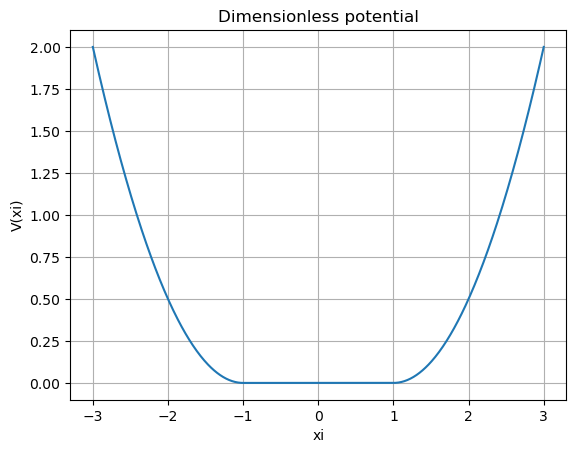

In [2]:
# Dimensionless potential
def dim_V(xi):
	if xi <= -1:
		return 1/2*(xi+1)**2
	elif abs(xi) < 1:
		return 0
	else:
		return 1/2*(xi-1)**2

# Space grid
xii, xif = -3, 3
dxi = 1e-2
N = int((xif - xii)/dxi)
xis = np.linspace(xii, xif, N)
Vs = [dim_V(xi) for xi in xis]

# Plotting
plt.plot(xis, Vs)
plt.xlabel("xi")
plt.ylabel("V(xi)")
plt.title("Dimensionless potential")

plt.grid()
plt.show()

## **Part (b): Trapping Analysis**

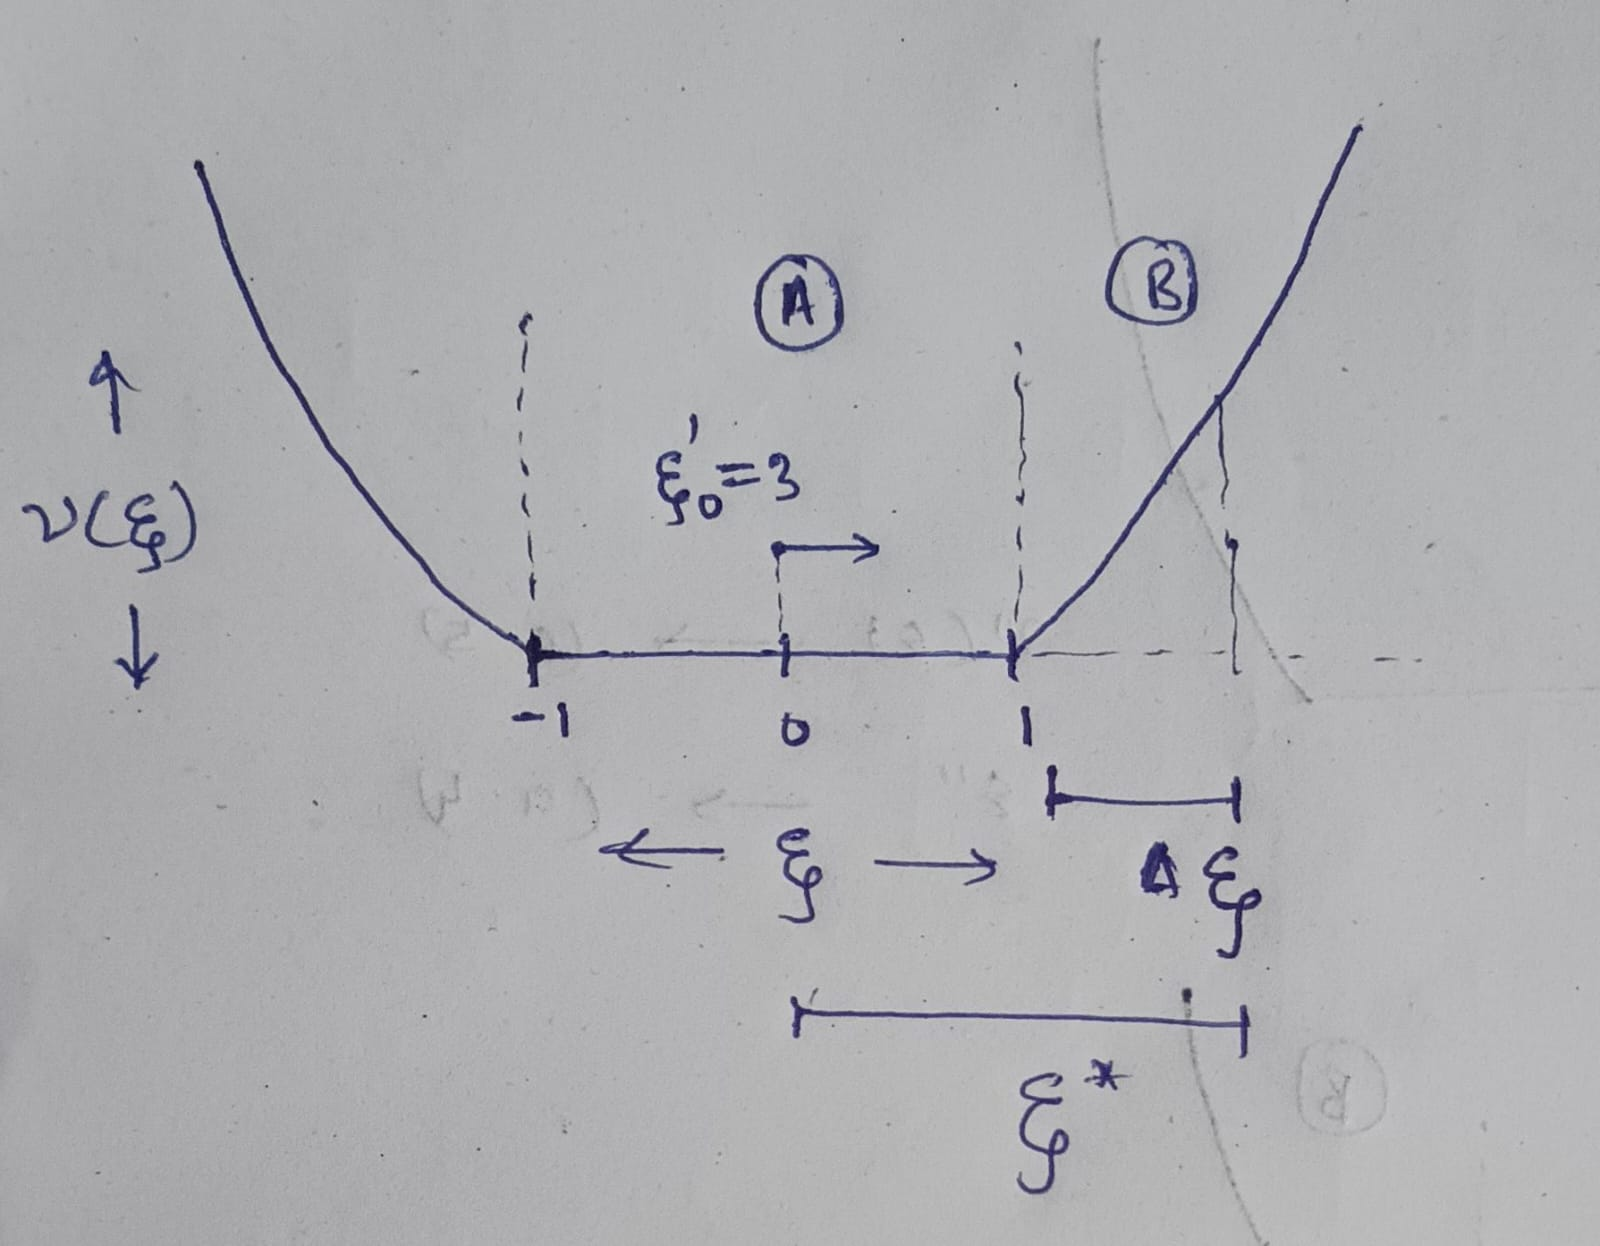

The journey can be divided into 2 parts - A & B, as shown in the figure above. From the diagram:
$$\xi^* = 1 + \Delta \xi$$

**Region (A):** $|\xi| < 1$

The particle starts its journey from $\xi(0) = 0$ with $\xi'(0) = 3$.

In this region:
$$\xi'' = -sgn(\xi') = -1$$
$$\implies \int_3^{\xi'} d\xi' = -\int_0^\tau d\tau \\
\implies \xi'(\tau) = 3 - \tau \tag{b.1}$$
$$\implies \int_0^\xi d\xi = \int_0^\tau (3 - \tau) d\tau \\
\implies \xi(\tau) = 3\tau - \frac{\tau^2}{2} \tag{b.2}$$

At $\xi = 1$:
$$1 = 3\tau - \frac{\tau^2}{2} \\
\implies \tau^2 - 6\tau + 2 = 0 \\
\implies \tau = 3 \pm \sqrt{7}$$

Taking the smaller root:
$$\tau = 3 - \sqrt{7}$$

Substituting this into (b.1):
$$\xi'(\tau) = \sqrt{7}$$
Hence, it reaches the wall at $\xi = 1$ with $\xi' = \sqrt{7}$

**Region (B):** $\xi \ge 1$

The particle enters the region with $\xi' = \sqrt{7}$.

$\therefore$ Initial energy = Kinetic energy = $\frac{1}{2}(\xi')^2$

$\therefore$ Energy lost due to drag = $f \cdot \Delta \xi = -sgn(\xi') \cdot \Delta \xi = \Delta \xi$ (since force and displacement are in opposite directions).

$\therefore$ Final energy = Potential energy = $\nu(\xi^*) = \frac{1}{2}(\xi^* - 1)^2 = \frac{1}{2}(\Delta \xi)^2$

*From energy conservation:*
$$\frac{1}{2}(\xi')^2 = \Delta \xi + \frac{1}{2}(\Delta \xi)^2 \\[5 pt]
\implies \Delta\xi^2 + 2\Delta\xi - 7 = 0 \\[5 pt]
\implies \Delta\xi = -1 \pm 2\sqrt{2}$$

Taking the positive root:
$$\Delta\xi = 2\sqrt{2}-1 \\
\implies \xi^* = 2\sqrt{2} \approx 2.828$$
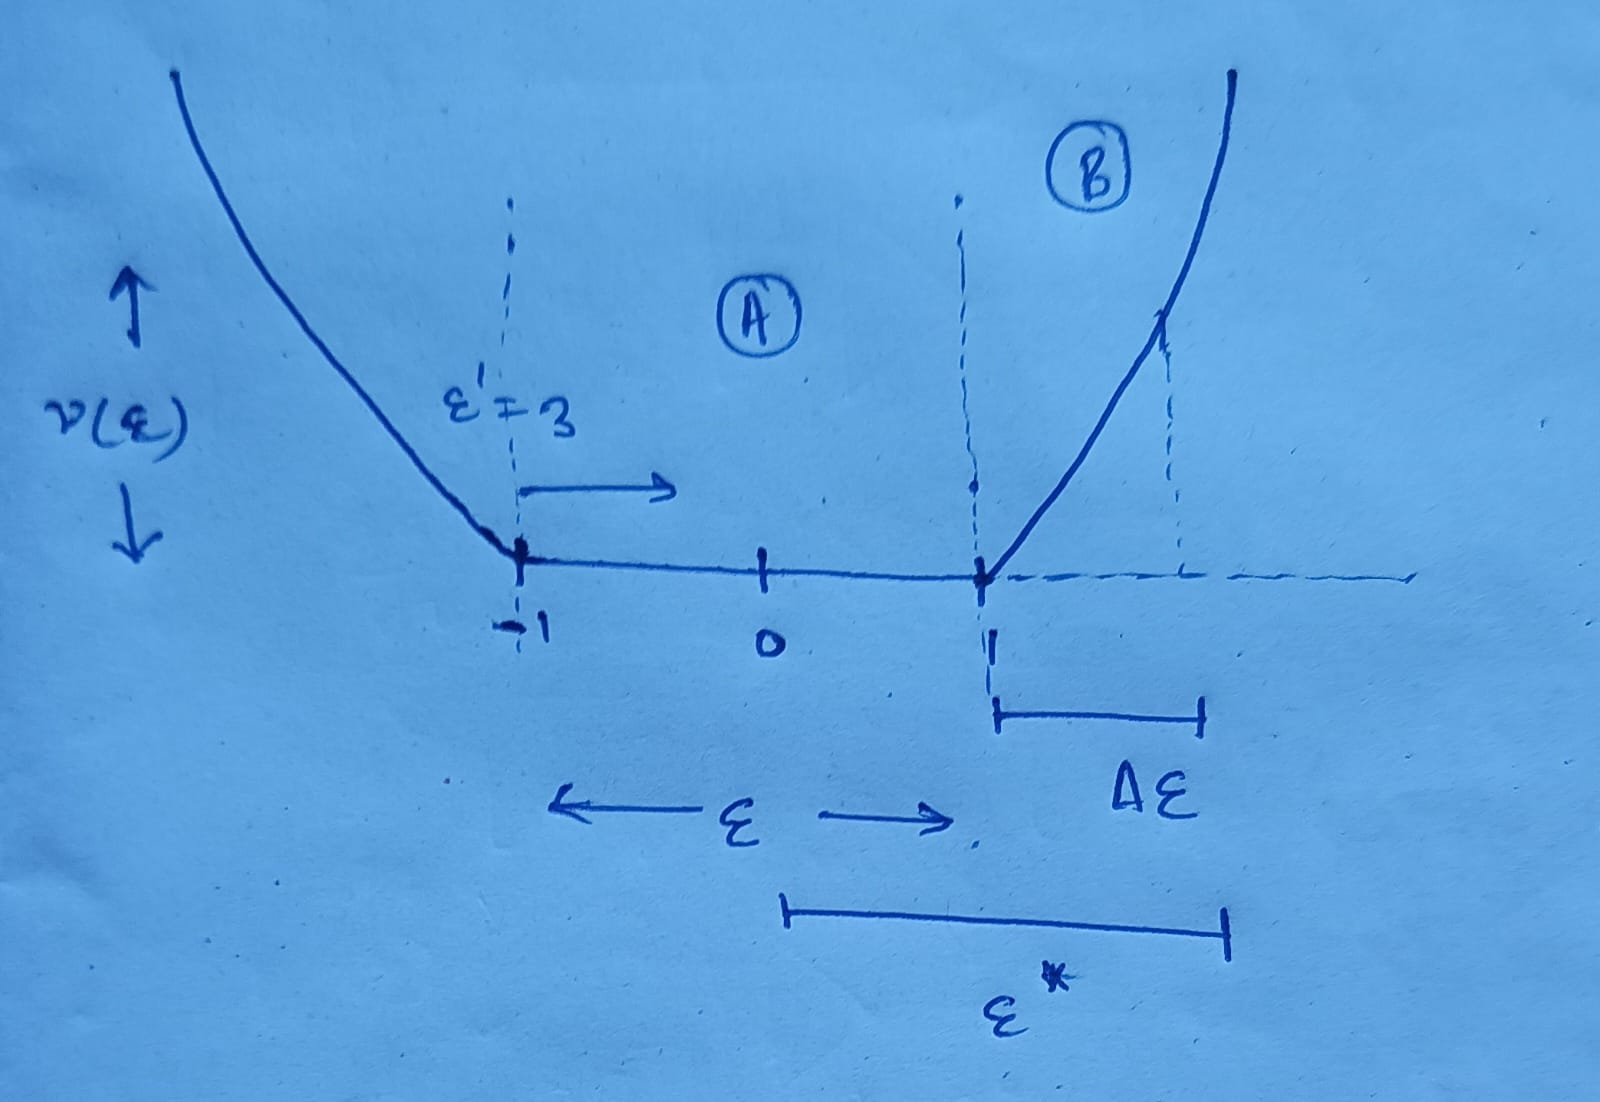

## **Part (c): RK4 Implementation**

**Region (A):** $|\xi| < 1$

We have the following differential equations:
$$\frac{d\xi}{d\tau} = \xi' \\[10 pt]
\xi'' = \frac{d\xi'}{d\tau} = -sgn(\xi')$$

Considering $\xi = y[0]$ and $\xi' = y[1]$:
$$\frac{d}{d\tau}
\begin{pmatrix}
    \xi \\
    \xi'
\end{pmatrix} = 
\begin{pmatrix}
    \xi' \\
    -sgn(\xi')
\end{pmatrix} \\[10 pt]
\implies \frac{d}{d\tau}
\begin{pmatrix}
    y[0] \\
    y[1]
\end{pmatrix} = 
\begin{pmatrix}
    y[1] \\
    -sgn(y[1])
\end{pmatrix}$$

**Region (B):** $\xi \ge 1$

Only the 2nd differential equation (acceleration) changes:
$$\xi'' = -(\xi-1)-sgn(\xi')$$

Hence, the combined form becomes:
$$\frac{d}{d\tau}
\begin{pmatrix}
    y[0] \\
    y[1]
\end{pmatrix} = 
\begin{pmatrix}
    y[1] \\
    -(y[0]-1)-sgn(y[1])
\end{pmatrix}$$

In [20]:
# RK4
def rk4(f1, x, y, h):
    s = np.sign(y[1])	# Evaluating sign once
    k1 = h * f1(x, y, s)
    k2 = h * f1(x + h / 2, y + k1 / 2, s)
    k3 = h * f1(x + h / 2, y + k2 / 2, s)
    k4 = h * f1(x + h, y + k3, s)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# Caller for RK4 method
def caller1(fn, y_ini, N, xs, h):
	y = y_ini
	ys = np.zeros((N, len(y_ini)), dtype=np.float64)
	i = 0
	# Checking if velocity stays below 1e-3 for 1 time unit
	counter = 0
	threshold_steps = int(1/h)

	while i<N:
		x = xs[i]
		ys[i, :] = y
		# Checking steps for which v is less than 1e-3
		if abs(y[1]) < 1e-3:
			counter += 1
		else:
			counter = 0
		# Break if velocity is less than 1e-3 for 1 time unit
		if counter >= threshold_steps:
			break

		y = rk4(fn, x, y, h)
		i += 1

	return ys[:i]

# d/dt[xi xi']
def f1(t, y, s):
	if abs(y[0]) < 1:	# flat region
		return np.array([y[1], -s])
	elif y[0] <= -1:	# left wall
		return np.array([y[1], -(y[0]+1) - s])
	else:	# right wall
		return np.array([y[1], -(y[0]-1) - s])

In [21]:
# Parameters
ti, tf = 0, 50
dt = 5e-3
N = int((tf-ti)/dt)+1
ts = np.linspace(ti, tf, N)

# Implementing RK4
Y0 = np.array([0, 3])	# Initial conditions
Ys = caller1(f1, Y0, N, ts, dt)
ys, vs = Ys[:, 0], Ys[:, 1]

# for i in range(len(vs)-1):
#     if vs[i]*vs[i+1] < 0:
#         xi_star = ys[i]
#         break
    
print(f"xi* = {ys[-1]}")

xi* = 1.1359928106424824


## **Part (d): Plots**

**Part (i):**

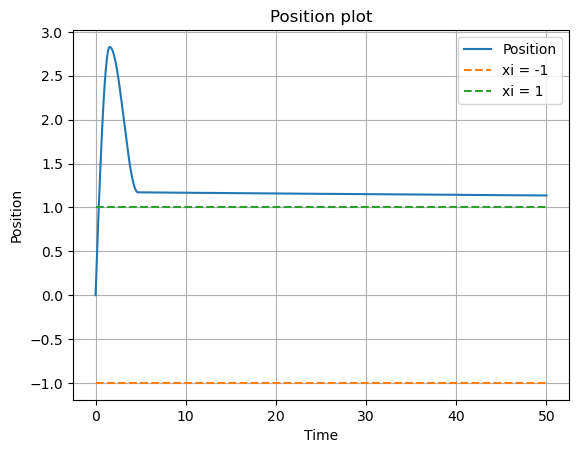

In [22]:
plt.plot(ts, ys, label = "Position")
plt.plot([ti, tf], [-1, -1], '--', label = "xi = -1")
plt.plot([ti, tf], [1, 1], '--', label = "xi = 1")
plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Position plot")
plt.legend()
plt.grid()
plt.show()

**Part (ii):**

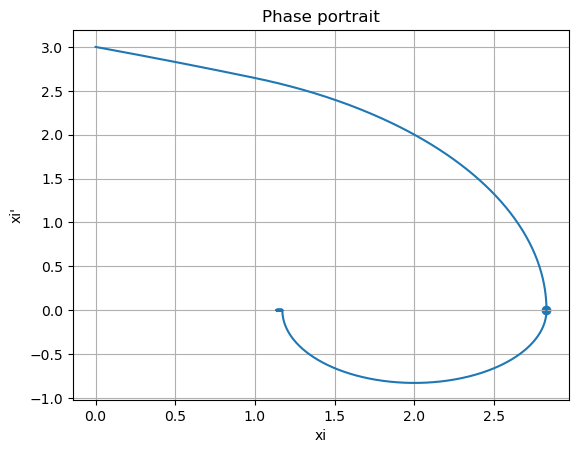

In [23]:
plt.plot(ys, vs)
plt.scatter(xi_star, 0)
plt.xlabel("xi")
plt.ylabel("xi'")
plt.title("Phase portrait")
plt.grid()
plt.show()